# Project data exploration - looking at relplot and scatter
Using a dataset that your group is consider using for the term project, let's do some data exploring of the different features in your dataset and their relationships

Group name:  Group 15
Created by: Seven (Stephani) Soriano (ID: ), Satyansh Rai (ID: ), Karla Nguyen (ID: 017111185), Jay Barrios Abarquez (ID: 017694040)
Last updated: 3/17/26  

Our dataset contains information about games available on the Steam platform. The original dataset included many features related to game metadata, developers, publishers, pricing information, and platform support. For the purpose of this project, we created a reduced dataset containing only the columns most relevant to our analysis, which are the game name, release date, initial price, final price, Metacritic score, total number of user recommendations, and whether the game is free to play.

Import your data. If you want to mount your Google drive you can use `from google.colab import drive` and `drive.mount('/content/drive')`

In [13]:
### Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

### Import data
steam_games = pd.read_csv("/steam_games_small.csv")

## Check the head of the data
steam_games.head()


,name,release_date,mat_initial_price,mat_final_price,metacritic_score,recommendations_total,is_free
0,Counter-Strike,2000-11-01,999.0,999.0,88.0,161854.0,False
1,Team Fortress Classic,1999-04-01,499.0,499.0,NaN,6633.0,False
2,Day of Defeat,2003-05-01,499.0,499.0,79.0,4308.0,False
3,Deathmatch Classic,2001-06-01,499.0,499.0,NaN,2338.0,False
4,Half-Life: Opposing Force,1999-11-01,499.0,499.0,NaN,22793.0,False


### Q1: Show the number of missing data in each column of the dataframe

In [14]:
### Show the number of missing data in each column of the df
steam_games.isna().sum()


,0
name,4
release_date,36855
mat_initial_price,94741
mat_final_price,94741
metacritic_score,234365
recommendations_total,217104
is_free,0


### Q2: Show the data type for each column of the dataframe

In [15]:
### Show the data type for each column of the df
steam_games.dtypes

,0
name,object
release_date,object
mat_initial_price,float64
mat_final_price,float64
metacritic_score,float64
recommendations_total,float64
is_free,bool


### Q3: Create a pair plot to show pairwise relationship in this dataset.
Draw the pairwise polynomial regression lines in a different color than the data points. Use a light color for the data points to deemphasizing the points to make the regression line stand out. Include a meaningful title to the plot.

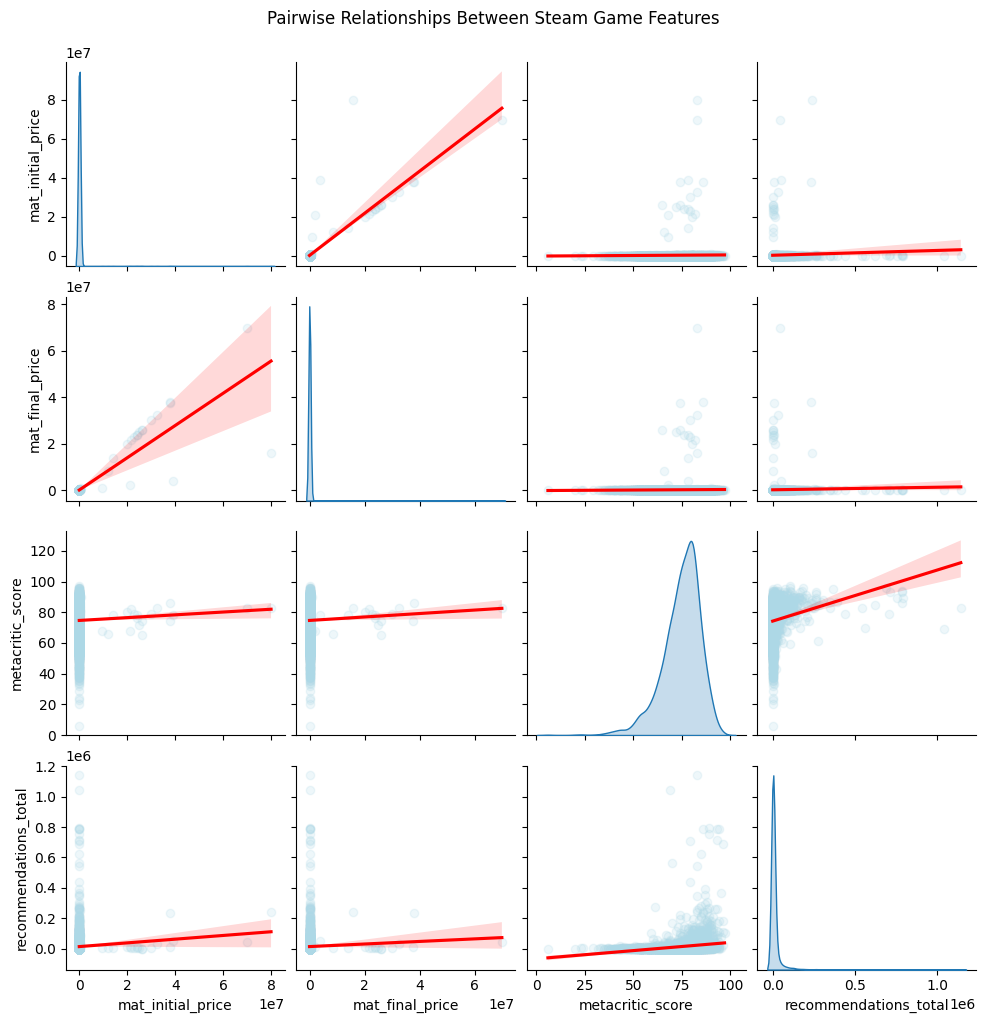

In [16]:
# Select float columns only
numeric_cols = steam_games.select_dtypes(include=['float64'])

# Drop missing values
clean_data_na = numeric_cols.dropna()

# Create pairplot
sns.pairplot(
    clean_data_na,
    kind="reg",
    diag_kind="kde",
    plot_kws={
        "scatter_kws": {"alpha": 0.2, "color": "lightblue"},
        "line_kws": {"color": "red"}
    }
)

plt.suptitle("Pairwise Relationships Between Steam Game Features", y=1.02)
plt.show()

### Q4: Plot a regression line and confidence interval
Select two of the features from your dataset and create a lmplot that shows the linear regression between them. Filter your data as you see fit. Include a meaningful title for the plot.

In [17]:
# Your code here . . .

### Q5. Create a relplot that shows multiple features in a single plot.
Select two features from your dataset and plot a scatter plot. Select two additional features you want to highlight in your data points using `hue` and `size`. Include a meaningful title to the plot.

In [18]:
# Your code here . . .

### Q6: Create a plot with small multiples plots
Select two features from your dataset and show the relationship between the features with an additional feature as the single category. Organize the multiple plots to have 3 plots per row. Set the `height` of the plot to 5 and the size the of data point to 20. Include a meaningful title in the plot.

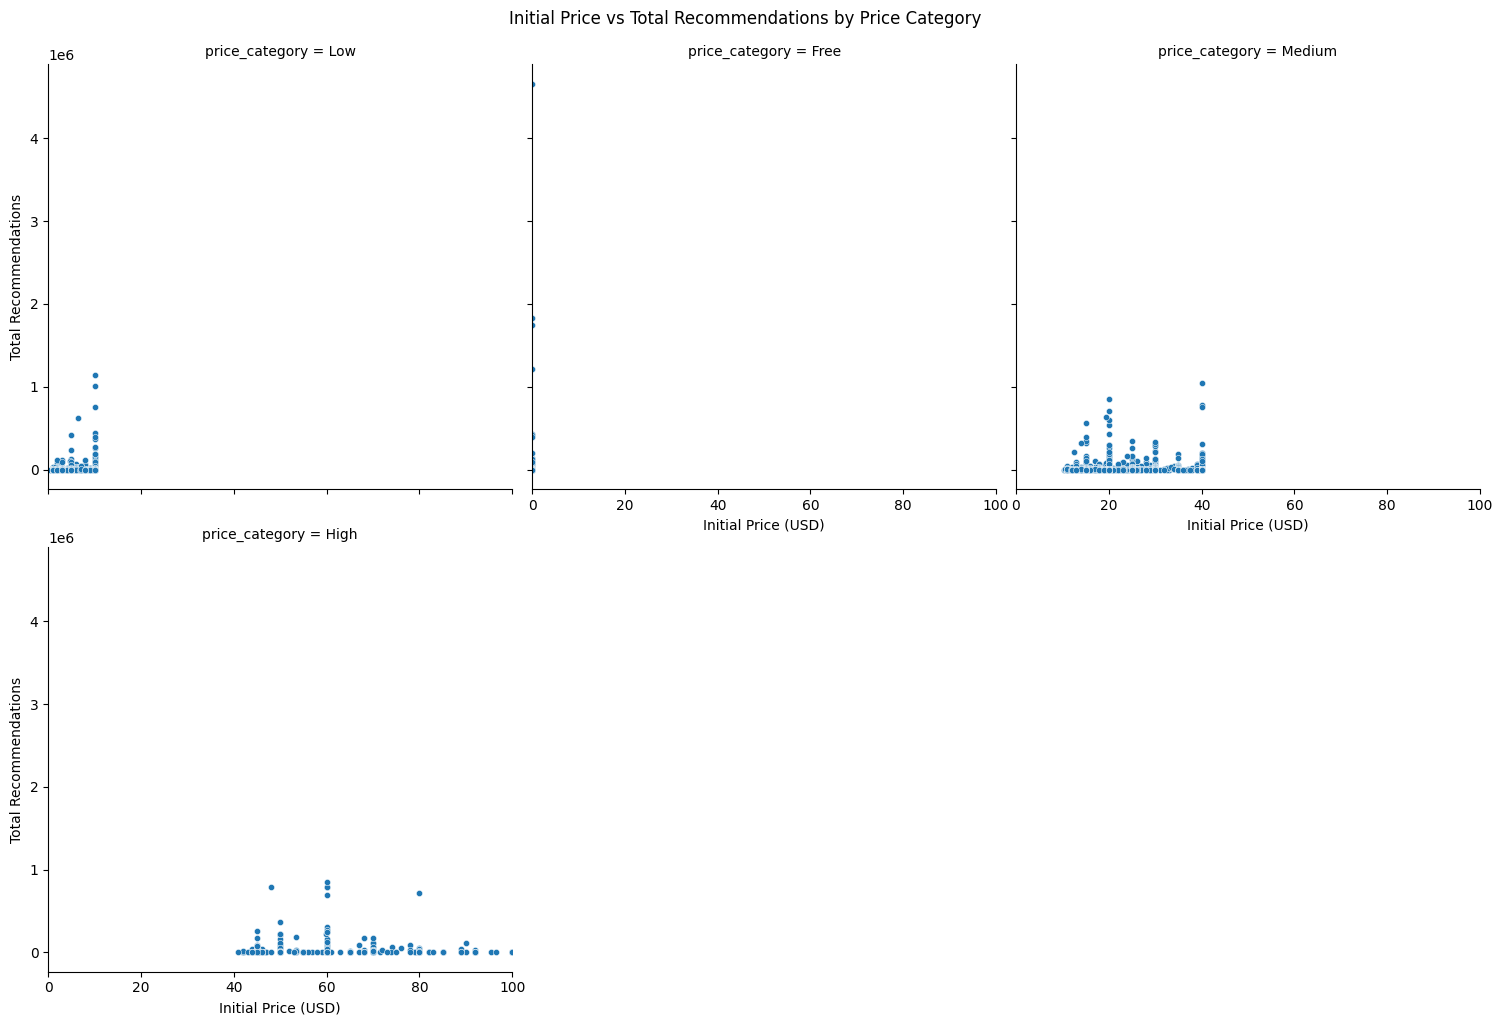

In [19]:
# Your code here . . .

## Note: games that are free have missing values for "mat_initial_price" and "mat_final_price",
##       so we will adjust those missing values to be 0 for free games before plotting. We will
##       also save this in a new df to avoid modifying the original data
steam_games_adjusted = steam_games.copy()
steam_games_adjusted["mat_initial_price"] = steam_games_adjusted["mat_initial_price"].fillna(0)
steam_games_adjusted["mat_final_price"] = steam_games_adjusted["mat_final_price"].fillna(0)

## The prices are also in cents, so we will convert them to dollars for easier interpretation
steam_games_adjusted["mat_initial_price"] = steam_games_adjusted["mat_initial_price"] / 100
steam_games_adjusted["mat_final_price"] = steam_games_adjusted["mat_final_price"] / 100

## Create a new column "price_category" to categorize games into "Free", "Low", "Medium", and "High" price categories
def categorize_price(price):
    if price == 0:
        return "Free"
    elif price > 0 and price <= 10:
        return "Low"
    elif price > 10 and price <= 40:
        return "Medium"
    else:
        return "High"
steam_games_adjusted["price_category"] = steam_games_adjusted["mat_initial_price"].apply(categorize_price)

## Create the scatter plot with subplots for each price category
mult_plot = sns.relplot(
    data=steam_games_adjusted,
    x="mat_initial_price",
    y="recommendations_total",
    col="price_category",
    kind="scatter",
    col_wrap=3,
    height=5,
    s=20
)

## Set the x-axis limits for all subplots to be the same for better comparison
## (there are some games that are extreme outliers, not typical for a customer's budget)
for ax in mult_plot.axes.flatten():
    ax.set_xlim(0, 100)

## Set the title and axis labels for the entire figure
mult_plot.fig.suptitle(
        "Initial Price vs Total Recommendations by Price Category",
        y=1.02 # Give a gap for the title to not overlap with the subplots
)
mult_plot.set_axis_labels("Initial Price (USD)", "Total Recommendations")
